In [1]:
%reload_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from collections import Counter
import torch
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from DataEncoder import encode_event_prefix_label, encode_pad_sequence, scale_time_differences, scale_time_differences_fast_fixed
from PrefixEmbeddingGCN import prepare_data, CustomDataset,  train, evaluate, EarlyStopping, custom_collate, PrefixGCNClassifier, f1_eva, get_misclassified_samples, cluster_errors
import os 
import shutil
import torch.nn as nn

/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.11/Python
  Referenced from: <75FFC412-93B5-322B-8E6D-268DA3498CF4> /opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/torch_geometric/typing.py:110: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: dl

In [2]:
#event = pd.read_csv("../output/BPI12.csv")
event = pd.read_csv("../output/BPI12w.csv")
#event = pd.read_csv("../output/BPI13i.csv")
#event = pd.read_csv("../output/BPI13c.csv")
#event = pd.read_csv("../output/helpdesk.csv")

In [3]:
# check the size of sequence
shortest_sequence = event.groupby('sequence').size().min()
longest_sequence = event.groupby('sequence').size().max()

print('shortest_sequence:', shortest_sequence)
print('longest_sequence:', longest_sequence)

shortest_sequence: 2
longest_sequence: 156


In [4]:
# prefix size 
prefix_size = 10
# Keep only sequence that have at least `prefix_size` members
event = event[event.groupby('sequence')['sequence'].transform('size') >= prefix_size].reset_index(drop=True)

In [5]:
#BPI13i
#cat_col_event = ['ec1', 'ec4']
#BPi12
event['ec1'] = event['ec1'].astype(str) 
cat_col_event = ['ec1']
#cat_col_event = []
#num_col_event = []
#helpdesk
#cat_col_event = ['ec1']
num_col_event = []
core_event = 'event'
case_index = 'sequence'
text_encode, event_encode, y_encode, text_size, output_dim = encode_event_prefix_label(event, core_event, cat_col_event, num_col_event, case_index, prefix_size, cat_mask=False, num_mask=False)

In [9]:
# sequence = event.groupby('sequence').apply(lambda x: x.iloc[prefix_size - 1:]).reset_index(drop=True)
sequence = event[event.groupby('sequence').cumcount() >= prefix_size - 1].reset_index(drop=True)

In [10]:
cat_col_seq = []
num_col_seq = ['sn1']
#BPI13c
#cat_col_seq = ['sc2','sc3']
#num_col_seq = []
#helpdesk
#cat_col_seq = ['sc1']
#num_col_seq = []
sequence_encode = encode_pad_sequence(sequence, cat_col_seq, num_col_seq)

In [11]:
start_time_col = 'time'
#start_time_col = 'StartTime'
scaled_time_diffs = scale_time_differences_fast_fixed(event, sequence, start_time_col, case_index)

In [12]:
num_sequences = event_encode.shape[0]
max_num_events = prefix_size
num_event_features = event_encode.shape[2]
num_sequence_features = sequence_encode.shape[1]
num_embedding_features = output_dim

In [13]:
event_feature_list = prepare_data(event_encode, text_encode, scaled_time_diffs)
sequence_features = torch.tensor(sequence_encode, dtype=torch.float)
y_encode = torch.tensor(y_encode, dtype=torch.long)

In [14]:
# Count occurrences of each class
class_counts = Counter(y_encode.numpy())
print("Class distribution:", class_counts)

# Find classes with only one sample
single_sample_classes = [cls for cls, count in class_counts.items() if count == 1]
print("Classes with only 1 sample:", single_sample_classes)

# Create mask to keep only classes with 2+ samples
mask = np.array([y not in single_sample_classes for y in y_encode.numpy()])

# Filter your data
filtered_indices = np.where(mask)[0]
filtered_event_features = [event_feature_list[i] for i in filtered_indices]
filtered_sequence_features = sequence_features[filtered_indices]
filtered_y = y_encode[filtered_indices]

print(f"Original samples: {len(event_feature_list)}")
print(f"Filtered samples: {len(filtered_event_features)}")
print(f"Removed {len(event_feature_list) - len(filtered_event_features)} samples")

# Now perform the split with filtered data
train_indices, test_indices = train_test_split(
    range(len(filtered_event_features)), 
    test_size=0.2, 
    stratify=filtered_y.numpy(), 
    random_state=42
)

# Split the filtered data
train_event_features = [filtered_event_features[i] for i in train_indices]
test_event_features = [filtered_event_features[i] for i in test_indices]
train_sequence_features = filtered_sequence_features[train_indices]
test_sequence_features = filtered_sequence_features[test_indices]
train_y = filtered_y[train_indices]
test_y = filtered_y[test_indices]

Class distribution: Counter({13: 17103, 15: 15002, 10: 11407, 12: 11400, 7: 8661, 16: 7666, 18: 7220, 9: 7190, 0: 5907, 17: 3980, 11: 2307, 14: 1713, 1: 136, 4: 92, 3: 91, 6: 83, 8: 34, 5: 33, 2: 16, 19: 12})
Classes with only 1 sample: []
Original samples: 100053
Filtered samples: 100053
Removed 0 samples


In [15]:
# Create datasets
train_dataset = CustomDataset(train_event_features, train_sequence_features, train_y)
test_dataset = CustomDataset(test_event_features, test_sequence_features, test_y)

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
num_event_features = num_event_features
gcn_hidden_dims = 32
num_embedding_features = num_embedding_features
embedding_dims = 16
gcn_hidden_dims_embedding = 32
gcn_hidden_dims_concat = 64
num_sequence_features = num_sequence_features
fc_hidden_dims = 32
fc_hidden_dims_concat = 64
output_dim = output_dim

model = PrefixGCNClassifier(num_event_features, 
                            gcn_hidden_dims,
                            num_embedding_features, 
                            embedding_dims,
                            gcn_hidden_dims_embedding, 
                            gcn_hidden_dims_concat,
                            num_sequence_features, 
                            fc_hidden_dims,
                            fc_hidden_dims_concat, 
                            output_dim).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 

In [17]:
# Create DataLoader with the loaded batch size
batch_size = 512
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate)

early_stopping = EarlyStopping(patience=3, delta=0.0)

# Filepath to save model
model_path = "../output/models/1BPI13i_prefix15_es.pt"

config = {
    'model_type': 'PrefixGCNClassifier',
    'num_event_features': num_event_features,
    'gcn_hidden_dims': gcn_hidden_dims,
    'num_embedding_features': num_embedding_features,
    'embedding_dims': embedding_dims,
    'gcn_hidden_dims_embedding': gcn_hidden_dims_embedding,
    'gcn_hidden_dims_concat': gcn_hidden_dims_concat,
    'num_sequence_features': num_sequence_features,
    'fc_hidden_dims':fc_hidden_dims,
    'fc_hidden_dims_concat':fc_hidden_dims_concat,
    'output_dim': output_dim
}


num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}")
    
    if early_stopping(test_loss):
        print("Early stopping triggered.")
        break

    if early_stopping.best_loss_updated:
        print(f"New best model at epoch {epoch+1}, saving to {model_path}")
        best_model_saved = True
         # Save state dict and config
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'config': config
        }, model_path)
        best_model = model
        
if not early_stopping.early_stop and not best_model_saved:
        print("Training completed without early stopping. Saving final model.")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'config': config
        }, model_path)
        best_model = model

Epoch 1/10 | Train Loss: 1.9559 Acc: 0.3871 | Test Loss: 1.6962 Acc: 0.5182
New best model at epoch 1, saving to ../output/models/1BPI13i_prefix15_es.pt
Epoch 2/10 | Train Loss: 1.5460 Acc: 0.5891 | Test Loss: 1.4247 Acc: 0.6398
New best model at epoch 2, saving to ../output/models/1BPI13i_prefix15_es.pt
Epoch 3/10 | Train Loss: 1.3758 Acc: 0.6466 | Test Loss: 1.3361 Acc: 0.6571
New best model at epoch 3, saving to ../output/models/1BPI13i_prefix15_es.pt
Epoch 4/10 | Train Loss: 1.3073 Acc: 0.6715 | Test Loss: 1.2855 Acc: 0.6872
New best model at epoch 4, saving to ../output/models/1BPI13i_prefix15_es.pt
Epoch 5/10 | Train Loss: 1.2582 Acc: 0.6908 | Test Loss: 1.2519 Acc: 0.6980
New best model at epoch 5, saving to ../output/models/1BPI13i_prefix15_es.pt
Epoch 6/10 | Train Loss: 1.2245 Acc: 0.6996 | Test Loss: 1.2180 Acc: 0.6916
New best model at epoch 6, saving to ../output/models/1BPI13i_prefix15_es.pt
Epoch 7/10 | Train Loss: 1.1998 Acc: 0.7069 | Test Loss: 1.2015 Acc: 0.7091
New be

In [18]:
#Final evaluation to get predictions and labels
model = best_model
class_report, top3_acc = f1_eva(model, test_loader, device, k=3)
_, top5_acc = f1_eva(model, test_loader, device, k=5)

print(f"Top-3 Accuracy: {top3_acc:.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}")

print("\nClassification Report (with F1 scores for each class):")
print(class_report)

/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

Top-3 Accuracy: 0.9718
Top-5 Accuracy: 0.9946

Classification Report (with F1 scores for each class):
              precision    recall  f1-score   support

           0     0.7578    0.2066    0.3247      1181
           1     0.5000    0.8148    0.6197        27
           2     0.0000    0.0000    0.0000         3
           3     0.0000    0.0000    0.0000        18
           4     0.2727    0.3333    0.3000        18
           5     0.0000    0.0000    0.0000         7
           6     0.0000    0.0000    0.0000        17
           7     0.7741    0.4827    0.5946      1732
           8     0.0000    0.0000    0.0000         7
           9     0.5416    0.8915    0.6739      1438
          10     0.6573    0.8852    0.7544      2282
          11     0.3478    0.0174    0.0331       461
          12     0.8054    0.7605    0.7823      2280
          13     0.8022    0.8524    0.8265      3421
          14     0.0000    0.0000    0.0000       343
          15     0.7996    0.8560

/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/gnn-pbpm/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [19]:
errors = get_misclassified_samples(model, test_loader, device)

Feature matrix shape: (5426, 600)


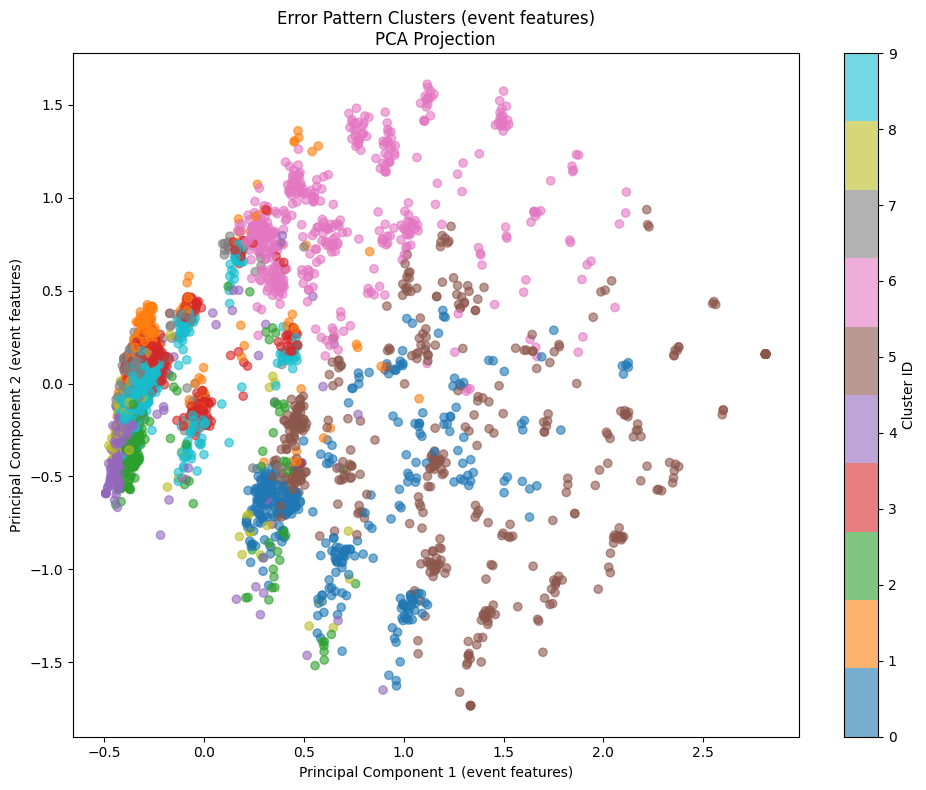

In [20]:
# Try different feature types and methods
num_clusters = 10
cluster_ids = cluster_errors(errors, num_clusters, use='event_feats')

In [21]:
# After running cluster_errors()
num_clusters = 10
for cluster_id in range(num_clusters):
    cluster_samples = [e for e, c in zip(errors, cluster_ids) if c == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_samples)} samples):")
    
    # Top error patterns
    from collections import Counter
    print("Common mistakes:", Counter((e['label'], e['pred']) for e in cluster_samples).most_common(3))
    
    # Average feature vector
    avg_features = np.mean([e['event_feats'] for e in cluster_samples], axis=0)
    print("Most salient features:", np.argsort(avg_features)[-5:])  # Top 5 influential features


Cluster 0 (354 samples):
Common mistakes: [((7, 9), 69), ((15, 13), 48), ((13, 15), 46)]
Most salient features: [[ 0 50 45 53 54 55 36 58 25 18 57 48  1 10  7 30 52  4 33  8 49 24 20 56
  51 17  3 22 13 26 31 34 32 23 44 14  2 12 21 27 39 15 38  6 35 28  9 19
   5 29 41 37 16 46 40 11 43 47 42 59]
 [ 0 36 58 50 24 48 18 53 54 10 45  1  7 57 55  8 33 30  3 25  4 52 20 56
  26 51 22 23 17 14 32 34 49 27 31 13 12  5 21 29  6 39 28 35 16  2 41 38
   9 44 15 43 46 37 40 19 11 47 42 59]
 [ 0 50 36 30 58 24 48 20 53 54 55 45  1 10 57  7 52 56 23 51 18  8 33  3
   4 49 25 26 32 14 35 17 22 31 34 39 12 27 13  5  6 21  2 29 41 38 28 15
  16 47  9 46 40 43 44 11 37 19 42 59]
 [ 0 50 53 36 30 58 24 45 55 56 48 57  1 10  7  8 51 52 25 20 54 18 33  3
   4 23 49 34 22 12 14 39 21 17 32 31  6 13 41 15 27 35 16  2 38  5 26 29
  47 28 44 43 11 40  9 46 19 42 37 59]
 [ 0 48 50 36 30 58 53 25 24 55 18 45  1 57  4 10 56  7 52  3 51 54 22 20
  15 33  8 49 32 23 34 16 14 17 39 21 41 12 11 31  6 38 13 47  5 

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(model_path, map_location=device)
config = checkpoint['config']

# Rebuild the model using the same config
model = PrefixGCNClassifier(
    num_event_features=config['num_event_features'],
    gcn_hidden_dims=config['gcn_hidden_dims'],
    num_embedding_features=config['num_embedding_features'],
    embedding_dims=config['embedding_dims'],
    gcn_hidden_dims_embedding=config['gcn_hidden_dims_embedding'],
    gcn_hidden_dims_concat=config['gcn_hidden_dims_concat'],
    num_sequence_features=config['num_sequence_features'],
    fc_hidden_dims=config['fc_hidden_dims'],
    fc_hidden_dims_concat=config['fc_hidden_dims_concat'],
    output_dim=config['output_dim']
)

model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)

# Rebuild optimizer (if needed)
optimizer = torch.optim.Adam(model.parameters())
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Create DataLoader with the loaded batch size
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate)

early_stopping = EarlyStopping(patience=3, delta=0.0)


In [23]:
start_epoch = checkpoint['epoch'] + 1 

for epoch in range(start_epoch, 10):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}")
    
    if early_stopping(test_loss):
        print("Early stopping triggered.")
        break

    if early_stopping.best_loss_updated:
        print(f"New best model at epoch {epoch+1}, saving to {model_path}")
        best_model_saved = True
         # Save state dict and config
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'config': config
        }, model_path)
        
if not early_stopping.early_stop and not best_model_saved:
        print("Training completed without early stopping. Saving final model.")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
            'config': config
        }, model_path)